In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import sys
print(sys.executable)

e:\sandyyyy\Mini project\MedSearch-RL\.venv\Scripts\python.exe


In [3]:
!{sys.executable} -m pip list

'e:\sandyyyy\Mini' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
from backend.datasets.mri_loader import load_sample

In [5]:
sample = load_sample("../data/figshare/brainTumorDataPublic_1533-2298/1534.mat")

In [6]:
mask = sample['mask']

In [7]:
import numpy as np

rows, cols = np.where(mask == 1)
print(rows.shape)
print(cols.shape)

(1262,)
(1262,)


In [8]:
# generating the bounding box
x_min = cols.min()
x_max = cols.max()

y_min = rows.min()
y_max = rows.max()

print(f"x_min = {x_min}")
print(f"y_min = {y_min}")
print(f"x_max = {x_max}")
print(f"y_max = {y_max}")

x_min = 262
y_min = 231
x_max = 303
y_max = 275


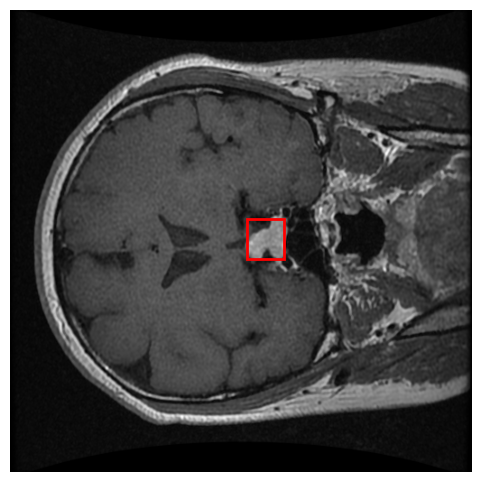

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image = sample['image']

fig,ax = plt.subplots(figsize=(6,6))

ax.imshow(image,cmap="gray")

rect = patches.Rectangle(
    (x_min,y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth = 2,
    edgecolor = 'red',
    facecolor = 'none'
)

ax.add_patch(rect)

plt.axis("off")
plt.show()

In [10]:
from backend.datasets.esad_loader import ESADLoader

loader = ESADLoader("../data/ESAD")

print(len(loader))

40152


In [11]:
sample = loader.load_sample(100)

print(sample.keys())
print(sample["domain"])

dict_keys(['image', 'boxes', 'labels', 'domain'])
ESAD


In [12]:
print(len(sample["boxes"]))
print(len(sample["labels"]))

1
1


In [13]:
from backend.datasets.mesad_loader import MESADLoader

loader = MESADLoader(
    "../data/mesad"
)

print(len(loader))

25390


In [14]:
sample = loader.load_sample(100)

print(sample.keys())
print(sample["domain"])
print(len(sample["boxes"]))
print(len(sample["labels"]))

dict_keys(['image', 'boxes', 'labels', 'domain'])
MESAD
1
1


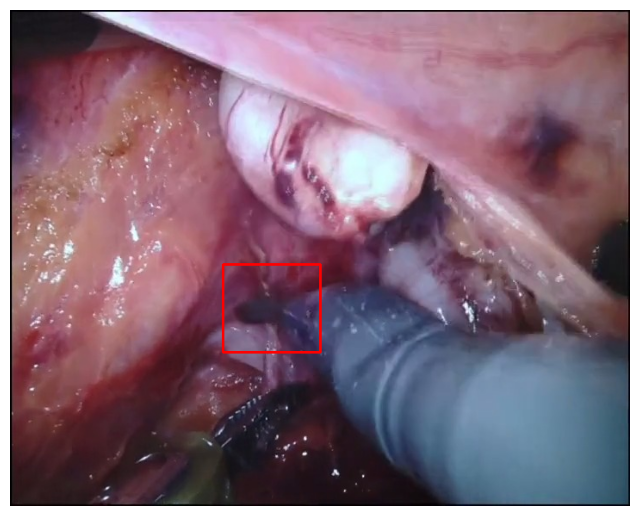

In [15]:
import cv2
import matplotlib.pyplot as plt

sample = loader.load_sample(100)

image = sample["image"].copy()

for box, label in zip(
    sample["boxes"],
    sample["labels"]
):

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [16]:
from backend.datasets.unified_dataset import UnifiedDataset

In [17]:
dataset = UnifiedDataset(
    mri_path="../data/figshare",
    esad_path="../data/ESAD",
    mesad_path="../data/mesad"
)

In [18]:
print(len(dataset))

68606


In [19]:
sample = dataset[0]

print(sample["domain"])

MRI


In [31]:
sample = dataset[3064]

print(sample["domain"])

ESAD


In [33]:
sample = dataset[44000]

print(sample["domain"])

MESAD


In [35]:
for idx in [0, 4000, 45000]:

    sample = dataset[idx]

    print(
        sample["domain"],
        sample.keys()
    )

MRI dict_keys(['image', 'mask', 'boxes', 'labels', 'domain', 'pid'])
ESAD dict_keys(['image', 'boxes', 'labels', 'domain'])
MESAD dict_keys(['image', 'boxes', 'labels', 'domain'])


In [36]:
print(dataset.mri_count)
print(dataset.esad_count)
print(dataset.mesad_count)

3064
40152
25390
